In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

In [2]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [43]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [44]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [45]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le forage 2025")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le forage 2025
Indice Y : 26
Indice X : 47
Latitude : 38.54820251464844
Longitude : 72.30000305175781
Altitude : 5300.28369140625


In [3]:
domain_2 = 'GRp'
domain_3 = 'GRp_bug'

In [4]:
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_bug='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_3 +'/spin2/work/monthly/'

In [32]:
#Before bug correction

variable='SMB' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_SMBb= xr.open_dataset(sourceData_bug+fileNameF).SMB.isel(SECTOR=0).load()

ds_SMBb = ds_SMBb.assign_coords(X=np.round(ds_SMBb.X.values))
ds_SMBb  = ds_SMBb.assign_coords(Y=np.round(ds_SMBb.Y.values))
ds_SMBb = ds_SMBb.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMBb = ds_SMBb[:,k:-k,k:-k]

ds_SMBb = ds_SMBb /1000
ds_SMBb.attrs['units'] = 'mWE/months' 

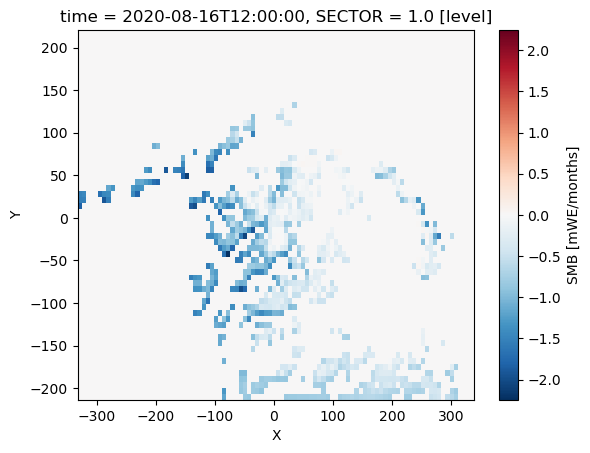

In [34]:
ds_SMBb.sel(time='2020-08-16T12:00').plot()

In [38]:
#After bug correction
variable='SMB' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1950-2024.nc'
ds_SMB= xr.open_dataset(sourceData+fileNameF).SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]
ds_SMB = ds_SMB /1000
ds_SMB.attrs['units'] = 'mWE/months' 

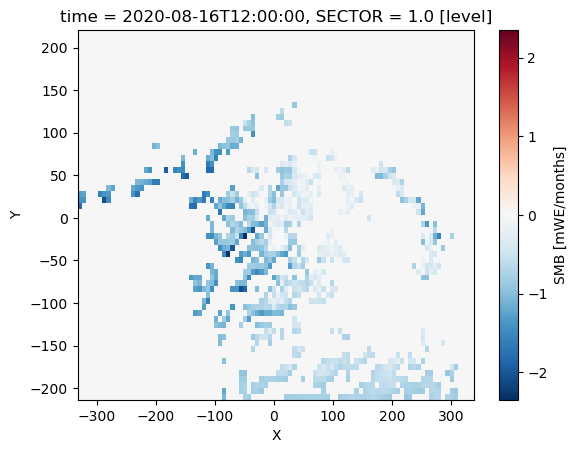

In [40]:
ds_SMB.sel(time='2020-08-16T12:00').plot()

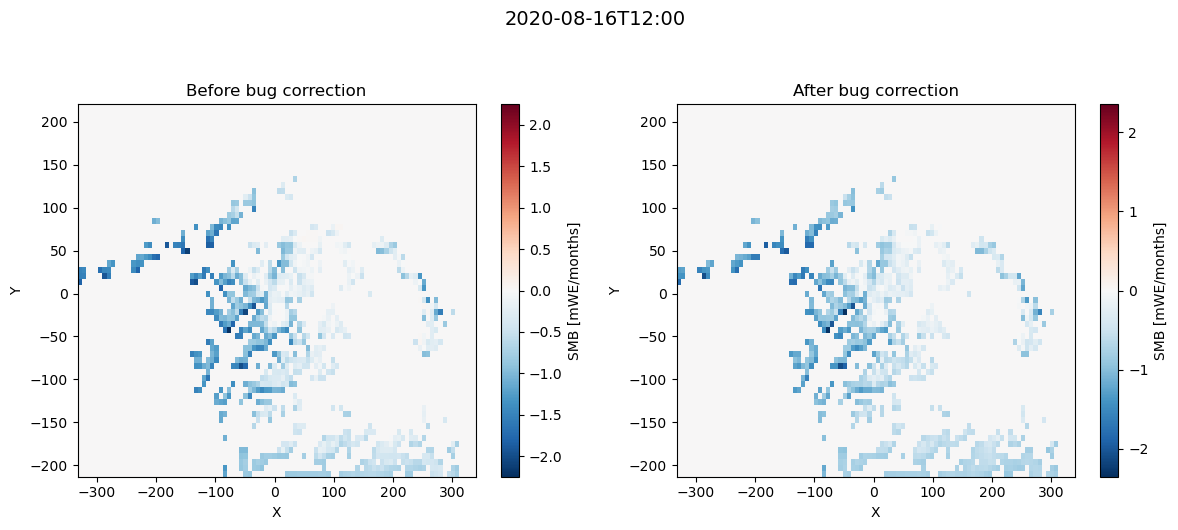

In [41]:
data1 = ds_SMBb.sel(time='2020-08-16T12:00')
data2 = ds_SMB.sel(time='2020-08-16T12:00')  # exemple avec un autre instant

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

data1.plot(ax=ax1)
ax1.set_title('Before bug correction')

data2.plot(ax=ax2)
ax2.set_title('After bug correction')

fig.suptitle('2020-08-16T12:00', fontsize=14, y=1.05)

plt.tight_layout()
plt.show()

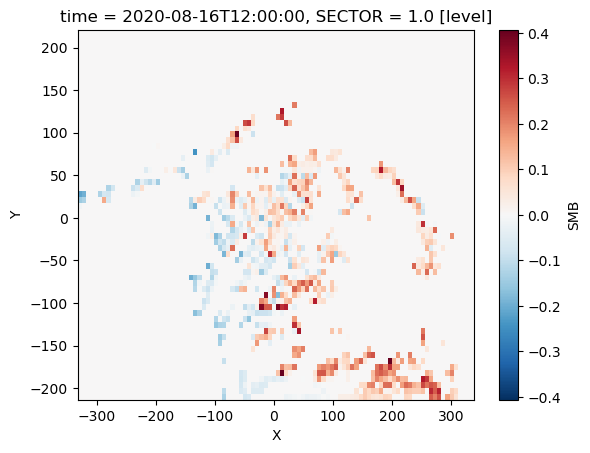

In [42]:
diff_smb= (ds_SMBb.sel(time='2020-08-16T12:00')-ds_SMB.sel(time='2020-08-16T12:00'))
diff_smb.plot()

In [47]:
ds_SMB_period = ds_SMB.sel(time=slice('1980-02-16T12:00', '2024-02-16T12:00'))
ds_SMBb_period = ds_SMBb.sel(time=slice('1980-02-16T12:00', '2024-02-16T12:00'))

# Sélection du point de grille du Forage Jasgulem
ds_SMB_point = ds_SMB_period.isel(Y=iY, X=iX)
ds_SMBb_point = ds_SMBb_period.isel(Y=iY, X=iX)

In [50]:
diff = ds_SMBb_point - ds_SMB_point

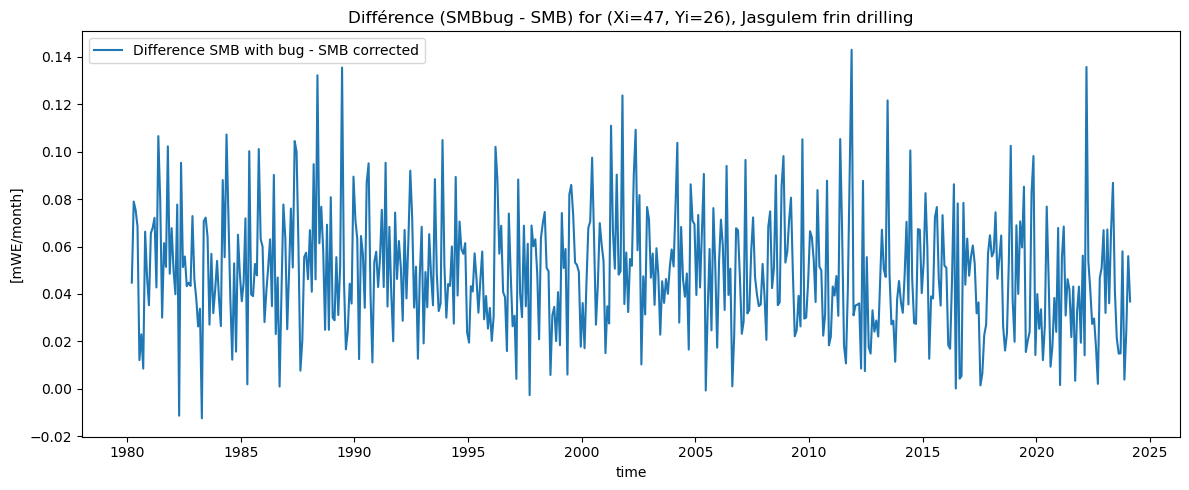

In [55]:
fig, ax = plt.subplots(figsize=(12, 5))
diff.plot(ax=ax, label='Difference SMB with bug - SMB corrected')

ax.set_title(f'Différence (SMBbug - SMB) for (Xi={iX}, Yi={iY}), Jasgulem frin drilling')
ax.set_ylabel('[mWE/month]')
ax.legend()

plt.tight_layout()
plt.show()